In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:

# To check convergence and mesh independency, the script is written as a function
# taking cell number and tend as inputs. For checking these two dependencies, the plotting 
# parts of the script should be manually commented as they are not needed

def mainf(n,tend,Ndeep,N00,kw):                           
    
    class parameters:
        def __init__(self,n,tend,Ndeep,N00,kw):


            # water column
            self.zwc = 30                      # depth of water column                          (m)
            self.zsed = 0.5                    # depth of sediment layer                        (m)
            self.zbot = self.zwc + self.zsed   # total depth                                    (m)
            self.n = n                         # number of cells                                (-)
            self.dz = self.zbot/self.n         # grid spacing                                   (m)
            self.v = 5                         # advection velocity (sinking)                   (m/day)
            self.kTop = 5                      # diffusivity coefficient at top                 (m^2/day)
            self.kBot = 1                      # diffusivity coefficient at bottom              (m^2/day)
            self.tstart = 0                    # start time of simulation                       (day)
            self.tend = tend                   # end of simulation                              (day)
            self.kw = kw                       # light attenuation by water                     (1/m)  
            self.kp = 0.05                     # light attenuation by phytoplankton             (1/(m.mmol N/m^3))
            self.dzwc = 1                      # thickness of grid cells in water column        (m)
            self.dzsed = 0.1                   # thickness of grid cells in sediment            (m)
            
            # Environment
            self.kL = 50.0                     # light half saturation                           (mu mol photon/(m^2.s))
            self.zMix = self.zwc/2             # depth at which diffusivity falls                (m)
            self.zetaMix = 2                   # thickness of stratification layer               (m)
            self.zMixW = 0.7*self.zwc          # zMix at winter 
            self.l0 = 1400                     # surface light intensity                         (mu mol photons/(m^2.s))


            # phytoplankton
            self.gPmax = 1.5                   # max growth rate                                 (1/day)
            self.mp = 0.25                     # mortality rate                                  (1/day)
            self.kz = 3.0                      # phytoplankton half saturation                   (mmol N/m^3)

            # Zooplankton
            self.gzmax = 0.7                   # zooplankton max grazing rate                    (1/day)
            self.e_res = 0.3                   # respiration fraction of zooplankton grazing     (-)
            self.e_eg = 0.3                    # egestion fraction of zooplankton grazing        (-)
            self.mz = 0.2                      # zooplankton mortality rate                      (1/day)

            # Detritus
            self.wD = 5.0                      # sinking velocity                                (m/day)
            self.r = 0.05                      # mineralization rate                             (1/day)

            #nutrients
            self.kN = 0.4                      # nutrient half saturation                        (mmol N/m^3)
            #self.Ndeep = Ndeep                 # nutrient concentration at deep layer            (mmol N/m^3)       
            self.kn = 10                       # bottom nutrient mixing rate                     (m/day)
            self.N00 = N00                     # Nutrient initial value in water column          (mmol N/m^3)

            # Oxygen
            self.yp = 9                        # yield factor O/N in photosynthesis                (mol O/ mol N) 
            self.yN = 6.625                    # yield factor O/N in respiration and decomposition (mol O/ mol N)
            self.O_atm = 260                   # atmospheric oxtgen                                (mmol O/m^3)                                                     
            self.k_top_o = 15                  # oxygen diffusion coefficient at sea surfaec       (m/day)                                               # ?????????????
            self.k_bot_o = 1                   # oxygen diffusion coefficient at bottom            (m/day)


    p=parameters(n,tend,Ndeep,N00,kw)


    # grid
    z = np.concatenate((np.arange(p.dz/2, p.zbot + p.dzwc/2, p.dzwc),                   # cell centers depth
                        np.arange(p.zwc + p.dzsed/2, p.zbot + p.dzsed/2, p.dzsed)))              

    zf = np.concatenate((np.arange(0, p.zwc, p.dzwc),
                         np.arange(p.zwc, p.zbot + p.dzsed, p.dzsed)))                  # cell faces depth

    def difco(t,p,zf):
        
        k = np.zeros(p.n+1) 
        zmixt = p.zMix    #+(1-np.sin((t-91)*2*np.pi/365))*(p.zMixW-p.zMix)/2
        k = 0.5*(1-np.tanh(((zf-zmixt)/p.zetaMix)))*(p.kTop-p.kBot)+p.kBot   

        return k


    def fluxes(phi, p, t, zf, v):
        
            Ja = np.zeros(p.n+1)
            Jd = np.zeros(p.n+1)

            Ja[1:-1] = v*phi[:-1]

            Ja[0] = 0                                   # default BC, unless specified later
            Ja[-1] = 0

            k = difco(t,p,zf)

            Jd[1:-1] = -k[1:-1]*(phi[1:]-phi[:-1])/p.dz

            Jd[0] = 0                                   # default BC, unless specified later
            Jd[-1] = 0

            return (Ja+Jd)

    def olf(o):                                         # oxygen limiting factor
        return 0.5*(1+np.tanh((o-100)/0.5))


    def light(t,z,P,D,p):
        
        I_sur = p.l0  #*( 1 + 0.3* (np.sin(2*np.pi*(t-91)/365)))
        I = I_sur*np.exp(-p.kw*z-np.cumsum(P+D)*p.dz*p.kp)

        return I


    def derivatives(t,y,p,zf):    

        N=y[0:p.n]
        P=y[p.n:2*p.n]
        D=y[2*p.n:3*p.n]
        Z=y[3*p.n:4*p.n]
        O=y[4*p.n:5*p.n]

        
        JN = fluxes(N, p, t, zf, 0)
        JN[-1] = -p.kn*(p.Ndeep-N[-1])/p.dz              # diffusion at the bottom

        JP = fluxes(P, p, t, zf, 0)                      
        JD = fluxes(D, p, t, zf, p.v)
        JZ = fluxes(Z, p, t, zf, 0)

        JO = fluxes(O, p, t, zf, 0)
        JO[0] = -p.k_top_o*(O[0]-p.O_atm)/p.dz           # air-sea diffusive exchange
        JO[-1] = -p.k_bot_o*(0-O[-1])/p.dz               # diffusion at bottom

        l = light(t,z,P,D,p)

        gP = p.gPmax * np.array([min(x,y) for x,y in zip(N/(p.kN+N), l/(l+p.kL))])
        gz = p.gzmax * P/(P + p.kz)


        dNdt = -(JN[1:]-JN[0:-1])/p.dz -gP*P + olf(O)*p.e_res*gz*Z + olf(O)*p.r*D         
        dPdt = -(JP[1:]-JP[0:-1])/p.dz + gP*P - olf(O)*gz*Z - p.mp*P               
        dDdt = -(JD[1:]-JD[0:-1])/p.dz + p.mp*P + p.mz*Z + olf(O)*p.e_eg*gz*Z - olf(O)*p.r*D    
        dZdt = -(JZ[1:]-JZ[0:-1])/p.dz + (1 - p.e_res - p.e_eg)*olf(O)*gz*Z - p.mz * Z
        dOdt = -(JO[1:]-JO[0:-1])/p.dz + p.yp*gP*P - olf(O)*p.yN*p.e_res*gz*Z - p.yN*olf(O)*p.r*D   

        return np.concatenate((dNdt, dPdt, dDdt, dZdt,dOdt))

    # Initial Values of State Variables ----------------------------------------------------------------------------------------------
    N0=p.N00*((z>=0) * (z<=3))
    P0=10*((z>=2) * (z<=4))
    D0=3*((z>=3) * (z<=4))
    Z0=1*((z>=5) * (z<=7))
    O0=2*((z>=0) * (z<=2))
    y0 = np.concatenate((N0,P0,D0,Z0,O0))


    # Solution -----------------------------------------------------------------------------------------------------------------------
    sol = solve_ivp(derivatives,t_span=(p.tstart,p.tend),y0=y0,method='LSODA',
                    args=(p,zf),rtol=1e-6,t_eval=np.arange(p.tstart,p.tend+1,1))


    t = sol.t
    N = sol.y[:p.n,:]
    P = sol.y[p.n:2*p.n,:]
    D = sol.y[2*p.n:3*p.n,:]
    Z = sol.y[3*p.n:4*p.n,:]
    O = sol.y[4*p.n:5*p.n,:]

    L = np.zeros((len(z),len(t)))

    for i in np.arange(0,len(t),1):
        
        L[:,i] = light(t[i],z,P[:,i],D[:,i],p)

    Phy_0 = P[0,-1]                       # To check convergence/mesh independency


    # Plots ----------------------------------------------------------------------------------------------

    # Line Graphs
    
    # Plotting N, P, Z

    plt.figure(figsize=(9,8))
    plt.subplot(2,2,1)
    plt.plot(N[:,-1],z,label='Nutrient N(mmol N/m^3)')
    plt.plot(P[:,-1],z,label='Phytoplankton P(mmol N/m^3)')
    plt.plot(Z[:,-1],z,label='Zooplankton Z(mmol N/m^3)')
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()
    plt.legend()

    # Plotting D 
    plt.subplot(2,2,2)
    plt.plot(D[:,-1],z,label='Detritus D(mmol N/m^3)')
    #plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()
    plt.legend()

    # Plotting O
    plt.subplot(2,2,3)
    plt.plot(O[:,-1],z,label='Oxygen O(mmol O2/m^3)')
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()
    plt.legend()

    # Plotting limiting factors on phytoplankton growth
    plt.subplot(2,2,4)
    plt.plot(L[:,-1]/(L[:,-1]+p.kL),z,label='Light Limitting Factor)')
    plt.plot(N[:,-1]/(N[:,-1]+p.kN),z,label='Nutrient Limitting Factor')
    #plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()
    plt.legend()

    # Colormaps --------------------------------------------------------------------------------------------------------------------------
    
    TT, ZZ = np.meshgrid(t,z)

    # Plotting Light Colormap
    plt.figure(figsize=(12,14),dpi=300)
    plt.subplot(3,2,1)
    plt.pcolormesh(TT, ZZ, L, shading='auto', cmap='viridis')
    plt.title('Light Intensity (mu mol photon/(m^2.s))')
    plt.colorbar()
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()

    # Plotting Nutrient Colormap
    plt.subplot(3,2,2)
    plt.pcolormesh(TT, ZZ, N, shading='auto', cmap='viridis')
    plt.title('Nutrient (m mol N/m^3)')
    plt.colorbar()
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()

    # Plotting Phytoplankton Colormap
    plt.subplot(3,2,3)
    plt.pcolormesh(TT, ZZ, P, shading='auto', cmap='viridis')
    plt.title('Phytoplankton (m mol N/m^3)')
    plt.colorbar()
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()

    # Plotting Nutrient Colormap
    plt.subplot(3,2,4)
    plt.pcolormesh(TT, ZZ, D, shading='auto', cmap='viridis')
    plt.title('Detritus (m mol N/m^3)')
    plt.colorbar()
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()

    # Plotting Zooplankton Colormap
    plt.subplot(3,2,5)
    plt.pcolormesh(TT, ZZ, Z, shading='auto', cmap='viridis')
    plt.title('Zooplankton (m mol N/m^3)')
    plt.colorbar()
    plt.xlabel('Time (day)')
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()

    # Plotting Oxygen Colormap
    plt.subplot(3,2,6)
    plt.pcolormesh(TT, ZZ, O, shading='auto', cmap='viridis')
    plt.title('Oxygen (m mol O2/m^3)')
    plt.colorbar()
    plt.xlabel('Time t(day)')
    plt.ylabel('Depth z(m)')
    plt.gca().invert_yaxis()


    return Phy_0, t, N, P, Z, D, O, L, z, p



Text(0, 0.5, 'Phytoplankton P(mmol N/m^3) at z=20 m')

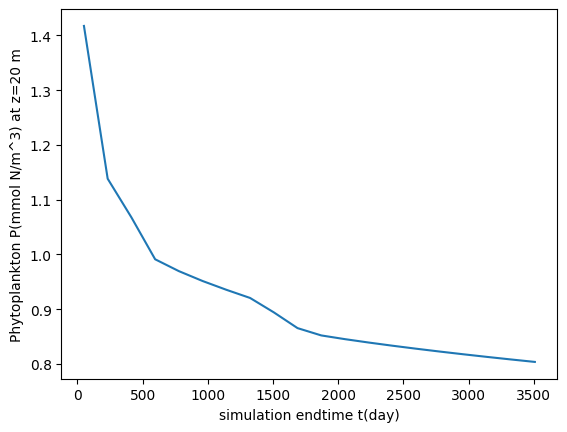

In [ ]:
# check convergence

tend=np.arange(50,365*10,182)
n_cell = 40
Pend = np.zeros(len(tend))
for i, value in enumerate(tend):
    Pend[i]=mainf(n_cell,value,Ndeep=50,N00=10,kw=0.15)[0]
plt.figure()
plt.plot(tend,Pend)
plt.xlabel('simulation endtime t(day)')
plt.ylabel('Phytoplankton P(mmol N/m^3) at z=0 m')



Text(0, 0.5, 'Phytoplankton P(mmol N/m^3) at z=0 m')

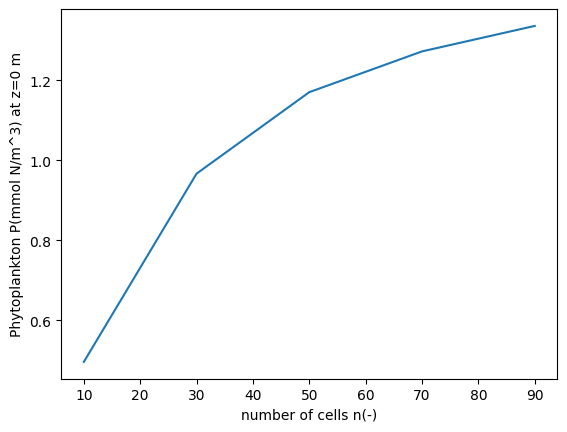

In [ ]:
# check mesh dependency

tend=365
n_cell = np.arange(10,91,20)
Pend = np.zeros(len(n_cell))
for i, value in enumerate(n_cell):
    Pend[i]=mainf(value,tend,Ndeep=50,N00=10,kw=0.15)[0]

plt.figure()
plt.plot(n_cell,Pend)
plt.xlabel('number of cells n(-)')
plt.ylabel('Phytoplankton P(mmol N/m^3) at z=0 m')

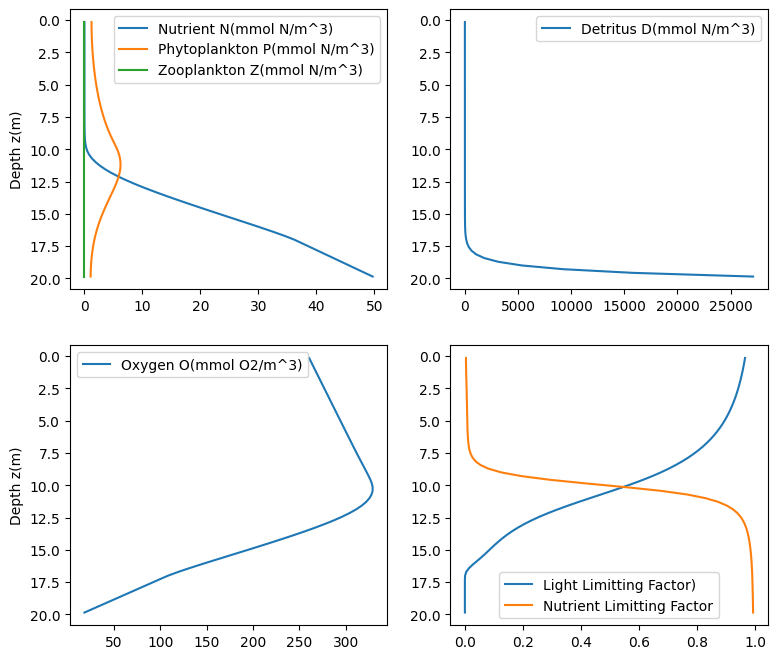

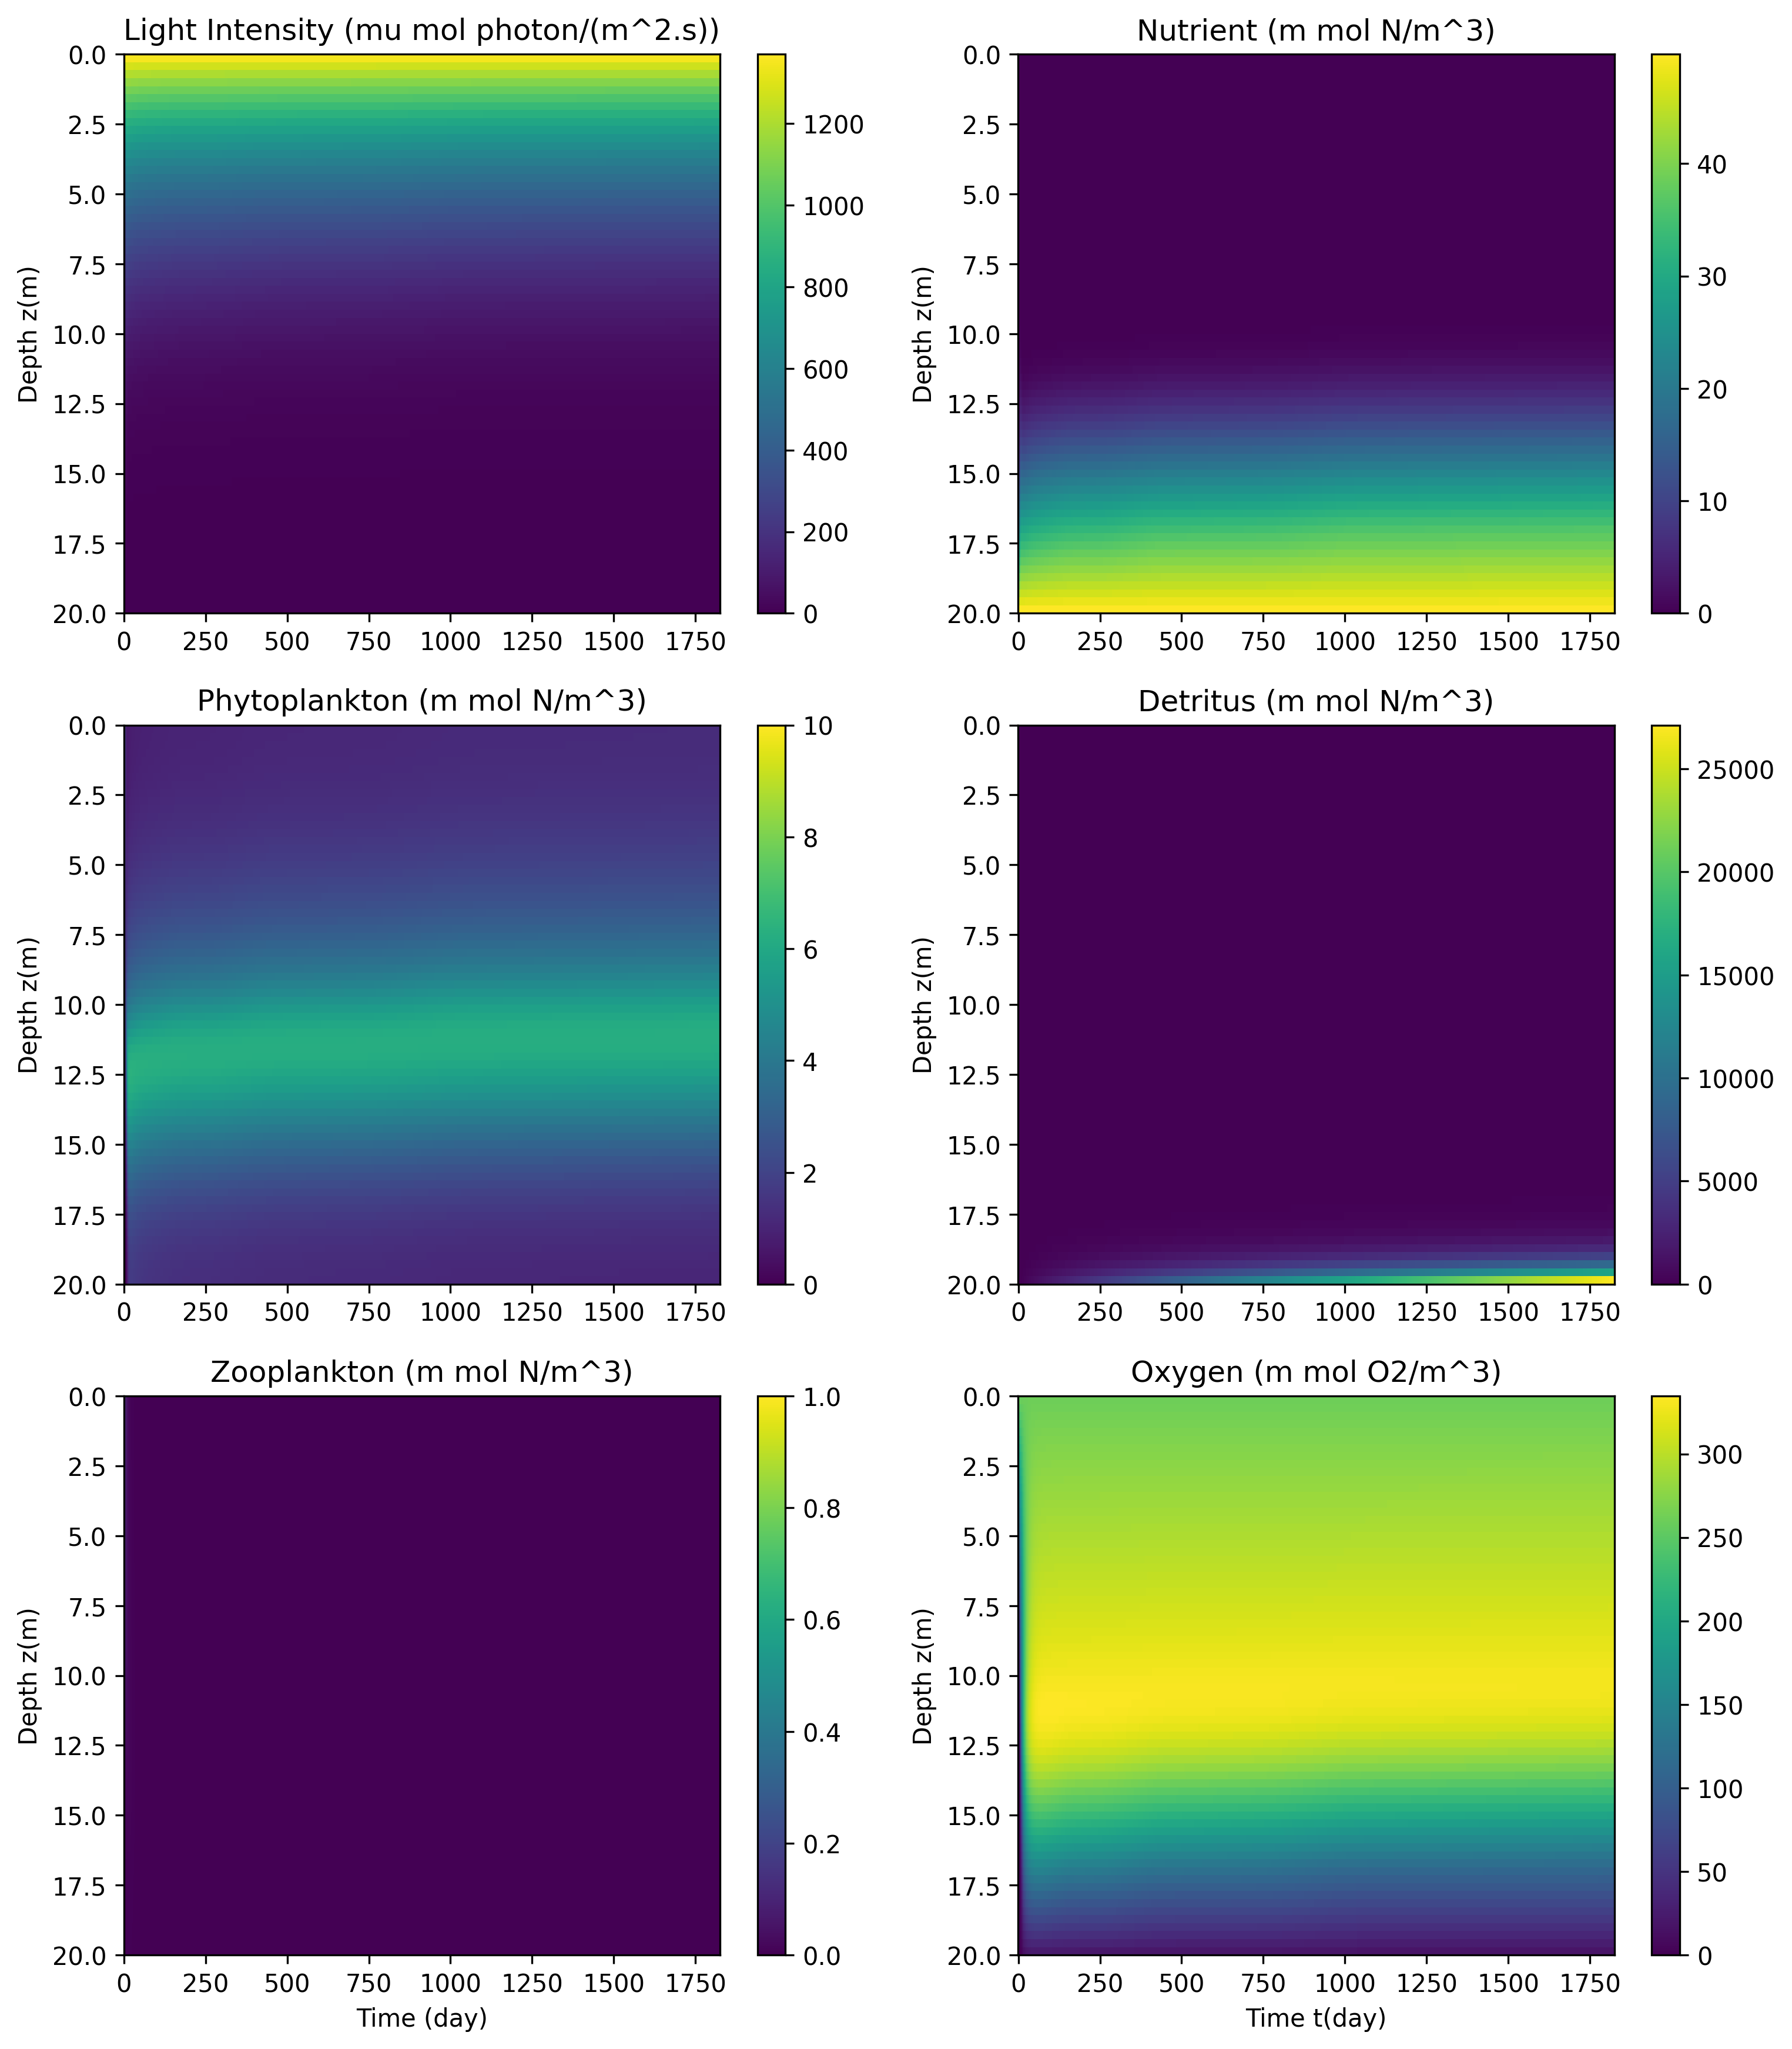

In [ ]:
Phy_0, t, N, P, Z, D, O, L, z, p= mainf(n=70,tend=5*365,Ndeep=50,N00=10,kw=0.15)

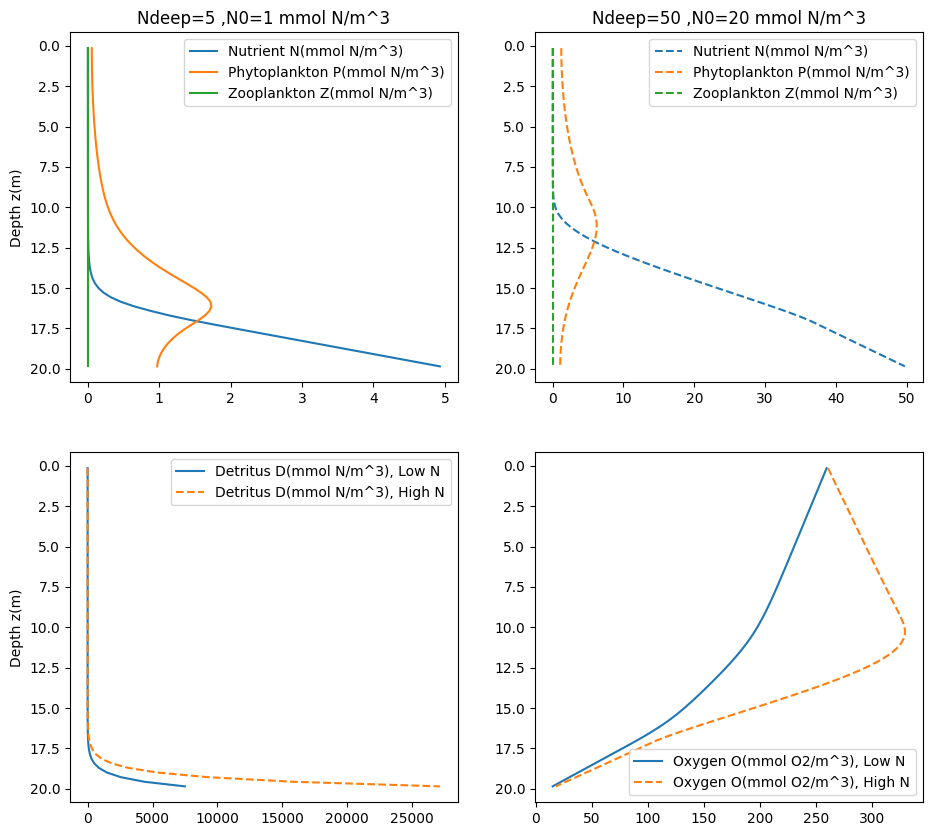

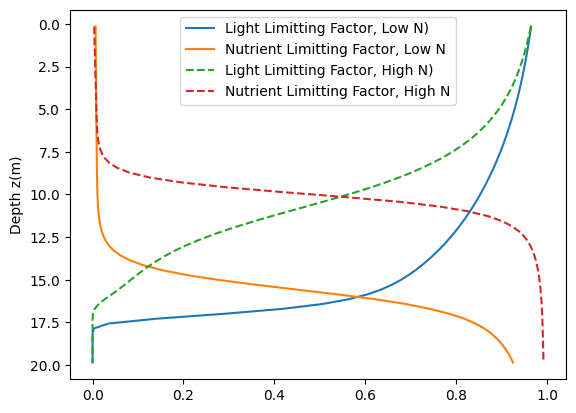

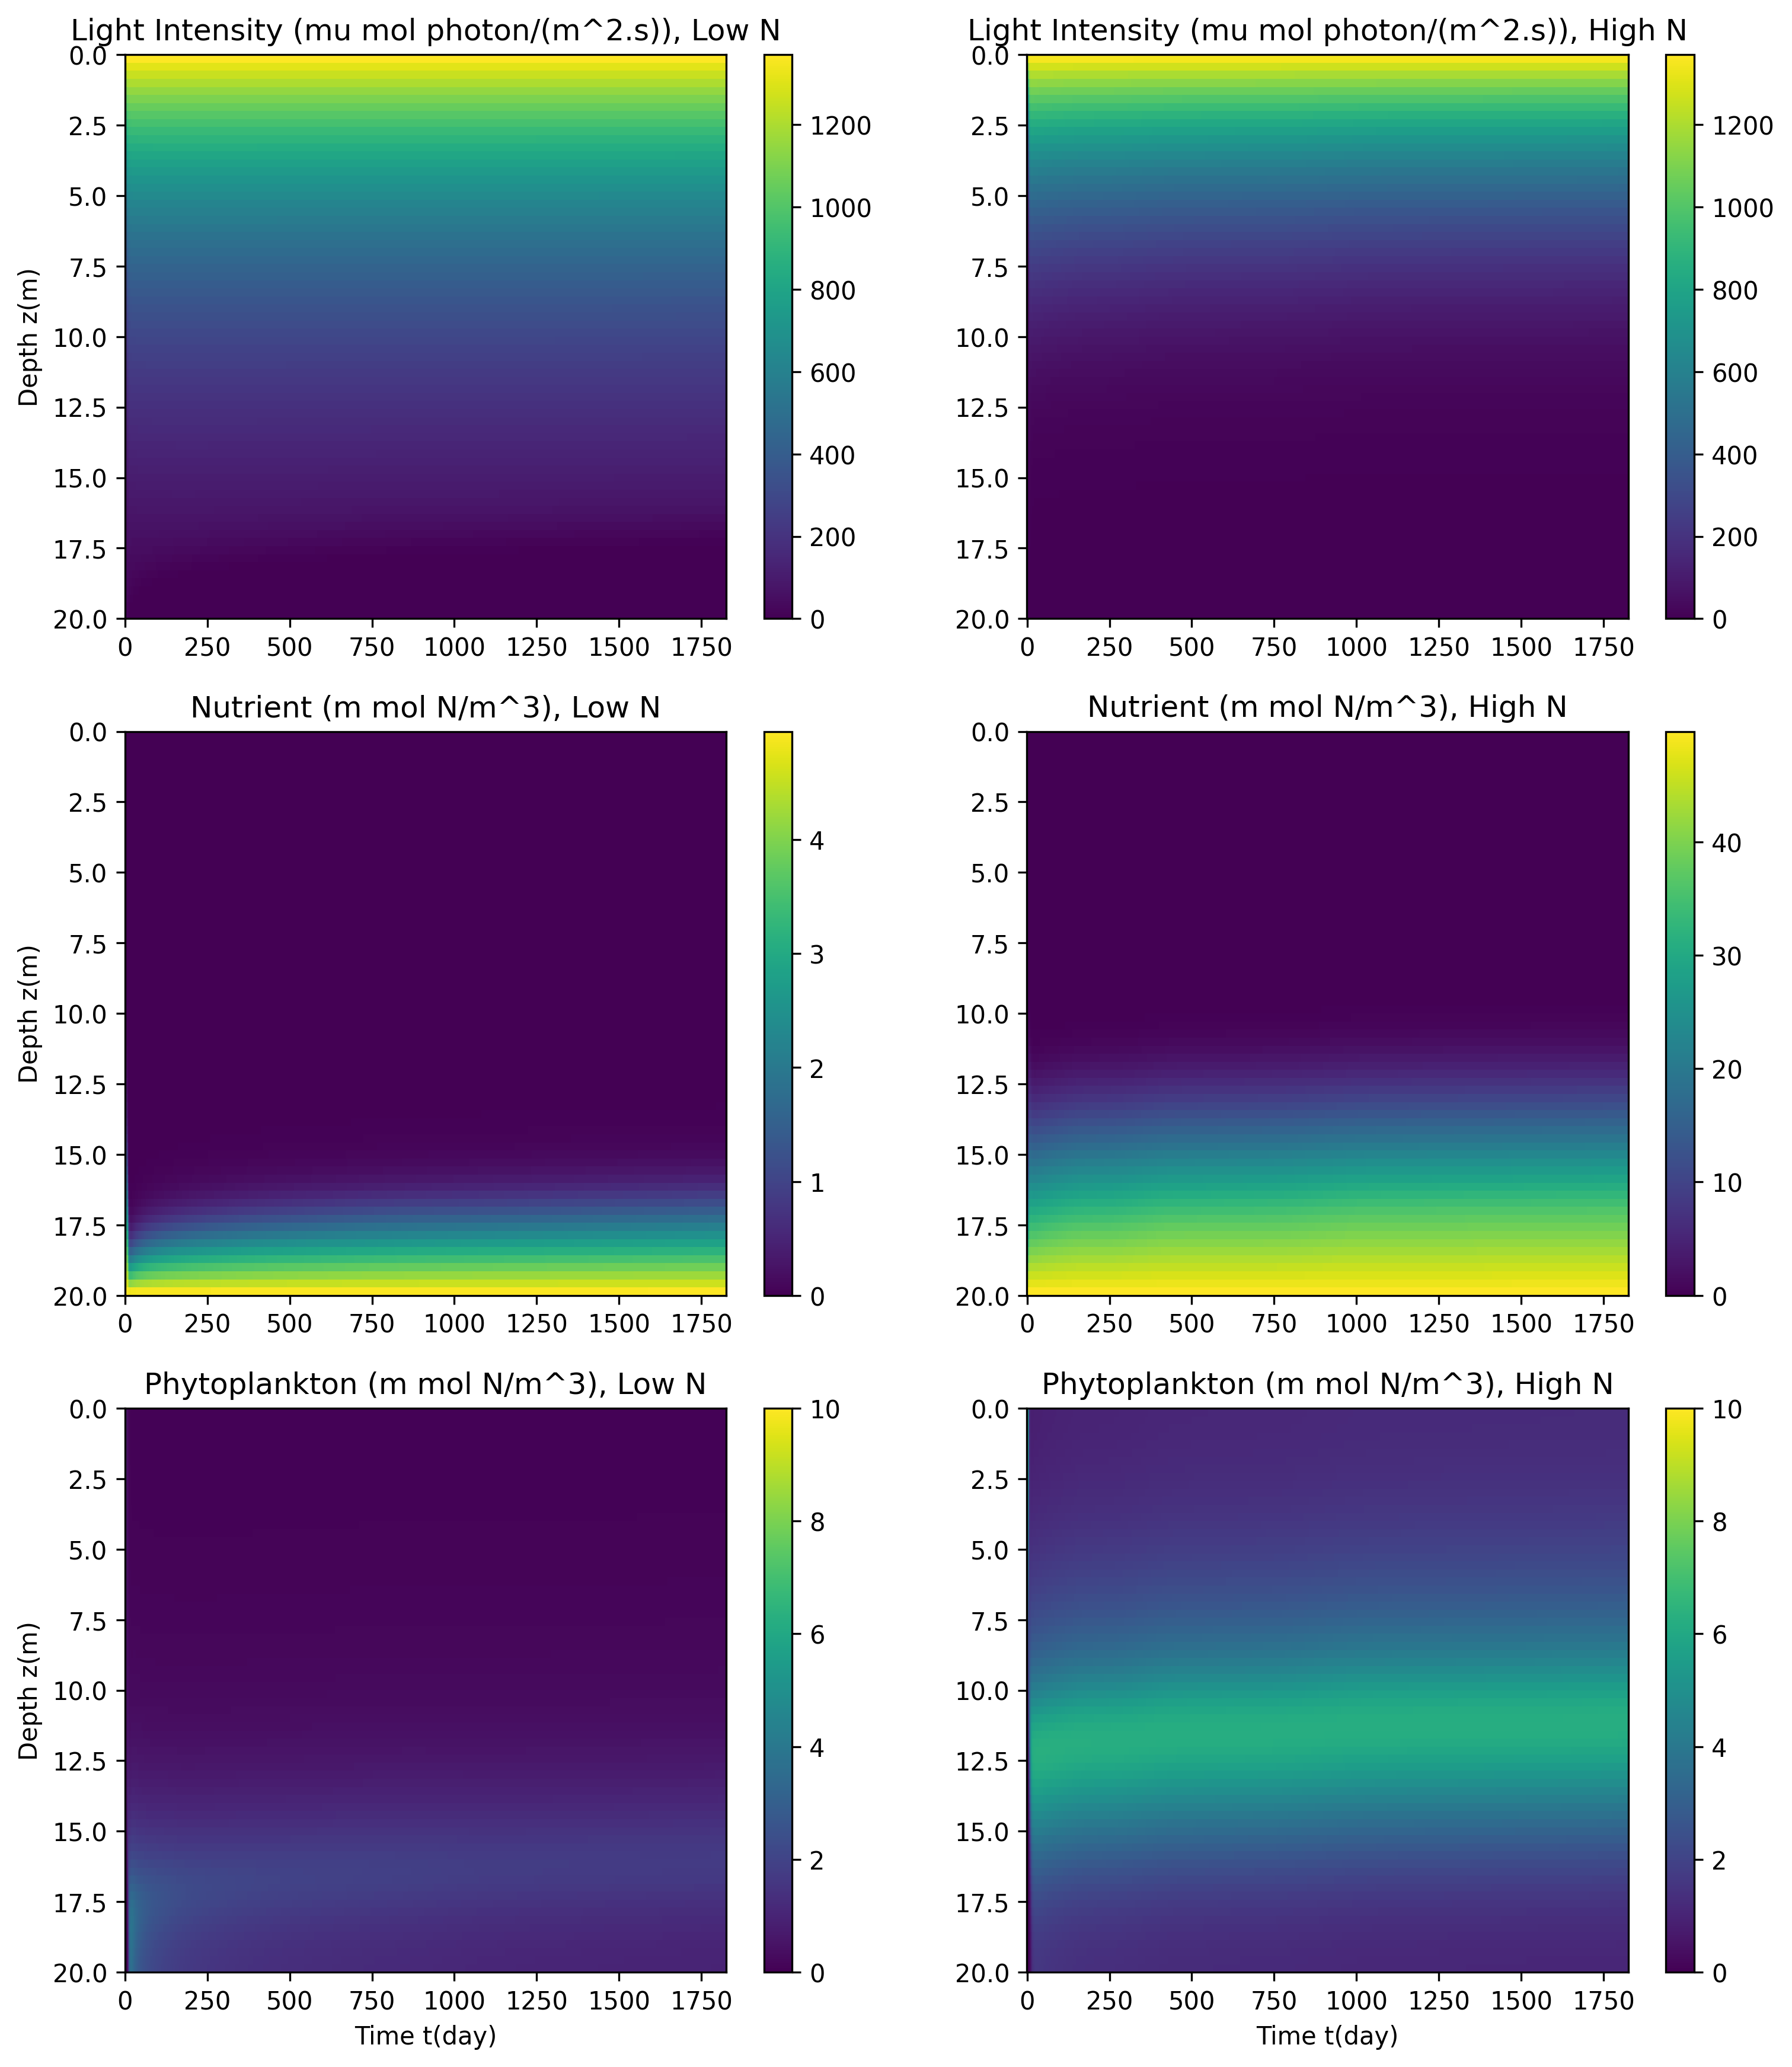

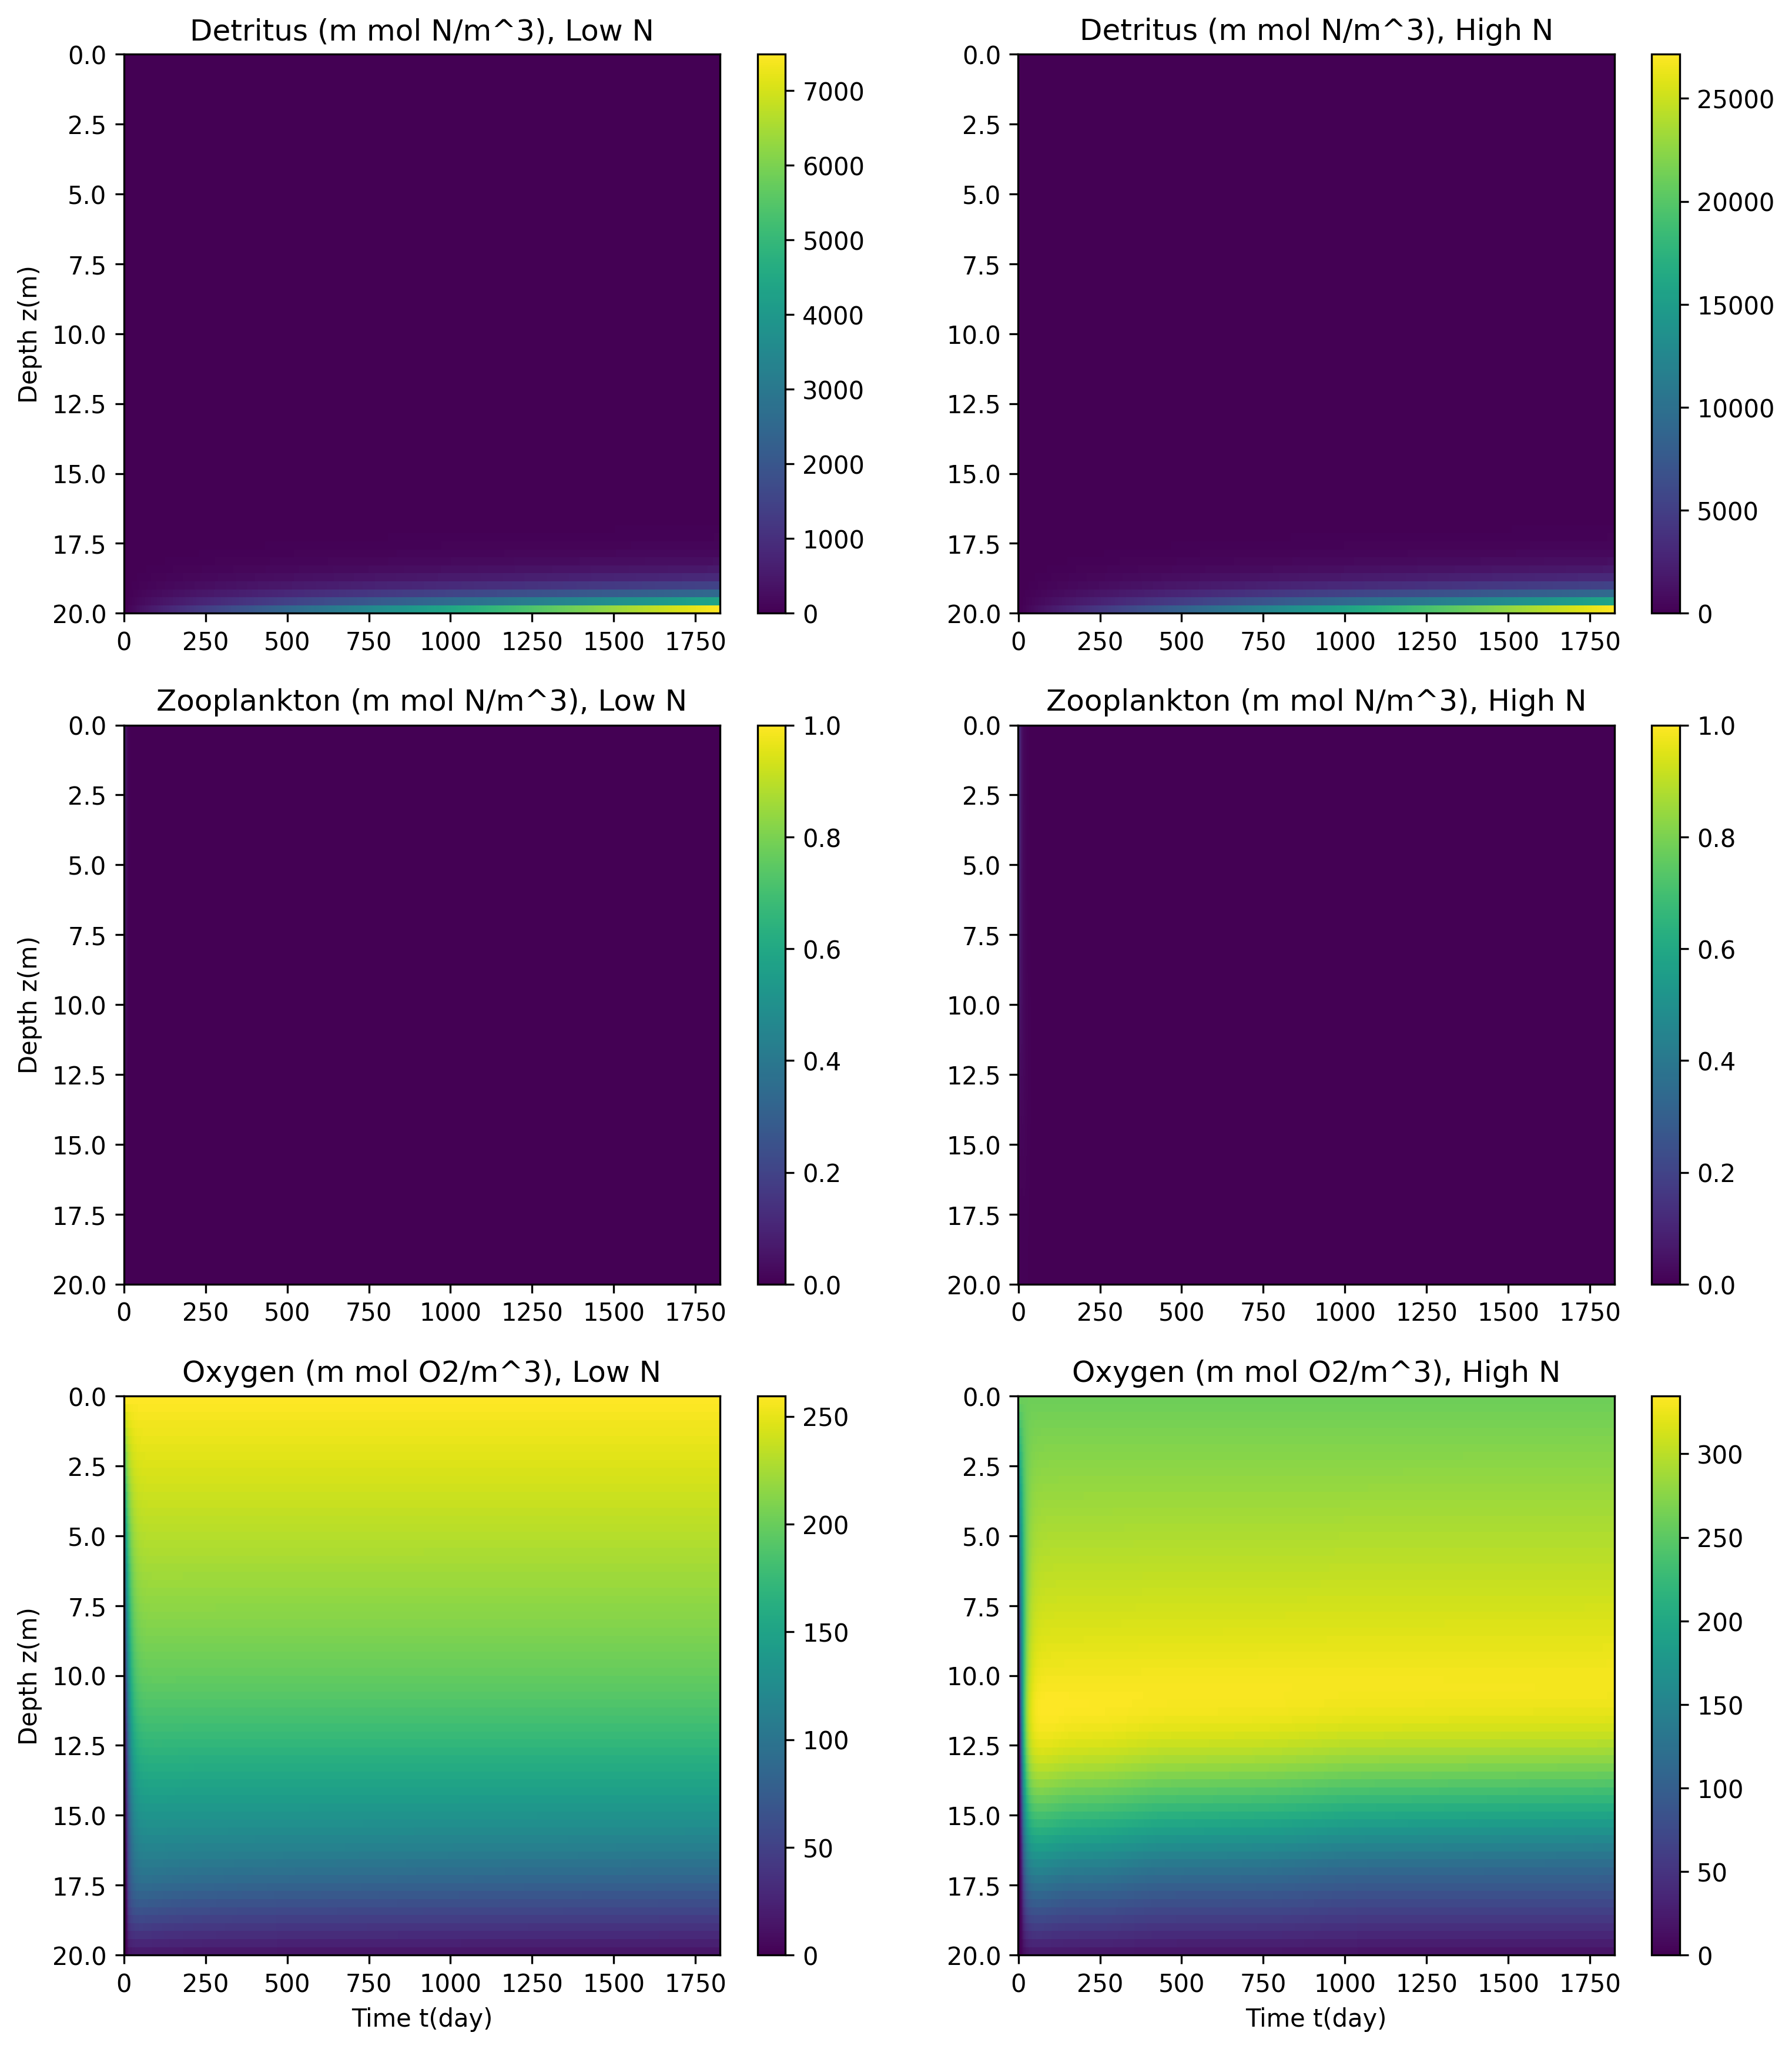

In [ ]:
# Q7

Phy_01, t, N1, P1, Z1, D1, O1, L1, z, p1= mainf(n=70,tend=5*365,Ndeep=5,N00=1,kw=0.15)
Phy_02, t, N2, P2, Z2, D2, O2, L2, z, p2= mainf(n=70,tend=5*365,Ndeep=50,N00=20,kw=0.15)

# Plotting N, P, Z

plt.figure(figsize=(11,10))
plt.subplot(2,2,1)
plt.plot(N1[:,-1],z,label='Nutrient N(mmol N/m^3)')
plt.plot(P1[:,-1],z,label='Phytoplankton P(mmol N/m^3)')
plt.plot(Z1[:,-1],z,label='Zooplankton Z(mmol N/m^3)')
plt.title('Ndeep=5 ,N0=1 mmol N/m^3')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()


plt.subplot(2,2,2)
plt.plot(N2[:,-1],z,'--',label='Nutrient N(mmol N/m^3)')
plt.plot(P2[:,-1],z,'--',label='Phytoplankton P(mmol N/m^3)')
plt.plot(Z2[:,-1],z,'--',label='Zooplankton Z(mmol N/m^3)')
plt.title('Ndeep=50 ,N0=20 mmol N/m^3')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Plotting D 
plt.subplot(2,2,3)
plt.plot(D1[:,-1],z,label='Detritus D(mmol N/m^3), Low N')
plt.plot(D2[:,-1],z,'--',label='Detritus D(mmol N/m^3), High N')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Plotting O
plt.subplot(2,2,4)
plt.plot(O1[:,-1],z,label='Oxygen O(mmol O2/m^3), Low N')
plt.plot(O2[:,-1],z,'--',label='Oxygen O(mmol O2/m^3), High N')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Plotting limiting factors on phytoplankton growth
plt.figure()
plt.plot(L1[:,-1]/(L1[:,-1]+p1.kL),z,label='Light Limitting Factor, Low N)')
plt.plot(N1[:,-1]/(N1[:,-1]+p1.kN),z,label='Nutrient Limitting Factor, Low N')
plt.plot(L2[:,-1]/(L2[:,-1]+p2.kL),z,'--',label='Light Limitting Factor, High N)')
plt.plot(N2[:,-1]/(N2[:,-1]+p2.kN),z,'--',label='Nutrient Limitting Factor, High N')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Colormaps --------------------------------------------------------------------------------------------------------------------------

TT, ZZ = np.meshgrid(t,z)

# Plotting Light Colormap
plt.figure(figsize=(12,14),dpi=300)
plt.subplot(3,2,1)
plt.pcolormesh(TT, ZZ, L1, shading='auto', cmap='viridis')
plt.title('Light Intensity (mu mol photon/(m^2.s)), Low N')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()


plt.subplot(3,2,2)
plt.pcolormesh(TT, ZZ, L2, shading='auto', cmap='viridis')
plt.title('Light Intensity (mu mol photon/(m^2.s)), High N')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Nutrient Colormap
plt.subplot(3,2,3)
plt.pcolormesh(TT, ZZ, N1, shading='auto', cmap='viridis')
plt.title('Nutrient (m mol N/m^3), Low N')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,4)
plt.pcolormesh(TT, ZZ, N2, shading='auto', cmap='viridis')
plt.title('Nutrient (m mol N/m^3), High N')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Phytoplankton Colormap
plt.subplot(3,2,5)
plt.pcolormesh(TT, ZZ, P1, shading='auto', cmap='viridis')
plt.title('Phytoplankton (m mol N/m^3), Low N')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.xlabel('Time t(day)')
plt.gca().invert_yaxis()

plt.subplot(3,2,6)
plt.pcolormesh(TT, ZZ, P2, shading='auto', cmap='viridis')
plt.title('Phytoplankton (m mol N/m^3), High N')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.xlabel('Time t(day)')
plt.gca().invert_yaxis()

# Plotting Nutrient Colormap
plt.figure(figsize=(12,14),dpi=300)
plt.subplot(3,2,1)
plt.pcolormesh(TT, ZZ, D1, shading='auto', cmap='viridis')
plt.title('Detritus (m mol N/m^3), Low N')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,2)
plt.pcolormesh(TT, ZZ, D2, shading='auto', cmap='viridis')
plt.title('Detritus (m mol N/m^3), High N')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Zooplankton Colormap
plt.subplot(3,2,3)
plt.pcolormesh(TT, ZZ, Z1, shading='auto', cmap='viridis')
plt.title('Zooplankton (m mol N/m^3), Low N')
plt.colorbar()
#plt.xlabel('Time (day)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,4)
plt.pcolormesh(TT, ZZ, Z2, shading='auto', cmap='viridis')
plt.title('Zooplankton (m mol N/m^3), High N')
plt.colorbar()
#plt.xlabel('Time (day)')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Oxygen Colormap
plt.subplot(3,2,5)
plt.pcolormesh(TT, ZZ, O1, shading='auto', cmap='viridis')
plt.title('Oxygen (m mol O2/m^3), Low N')
plt.colorbar()
plt.xlabel('Time t(day)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,6)
plt.pcolormesh(TT, ZZ, O2, shading='auto', cmap='viridis')
plt.title('Oxygen (m mol O2/m^3), High N')
plt.colorbar()
plt.xlabel('Time t(day)')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

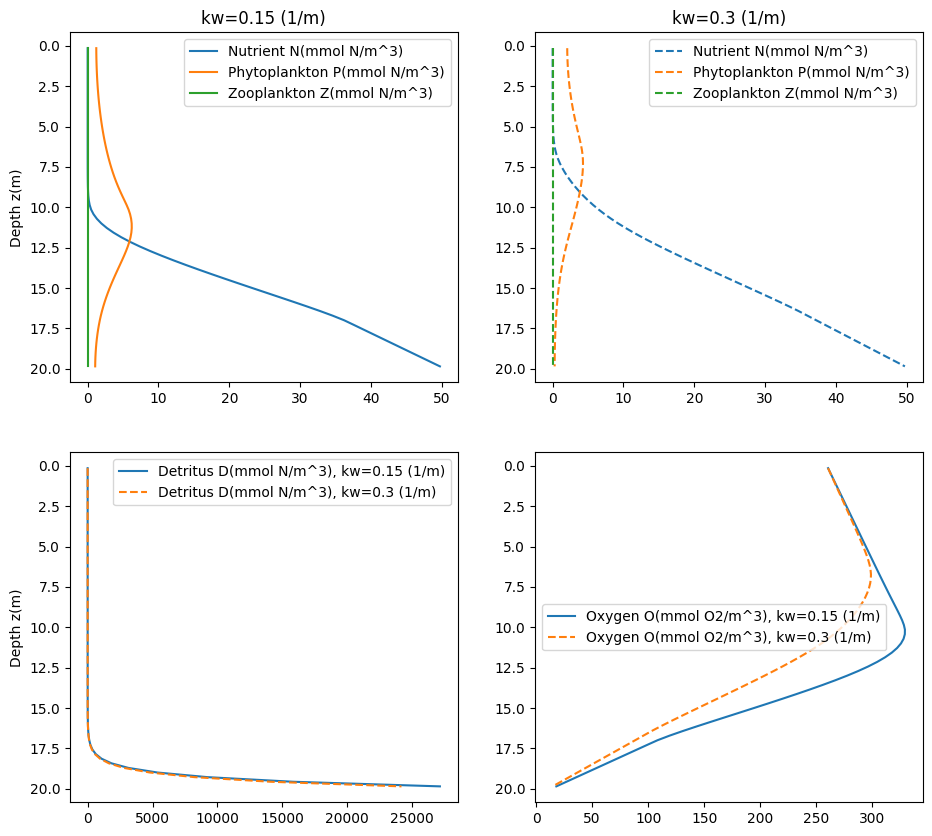

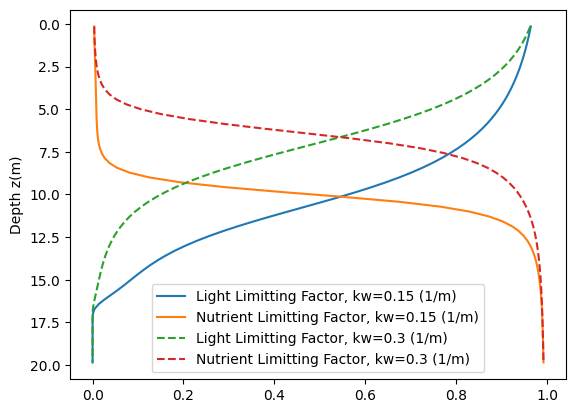

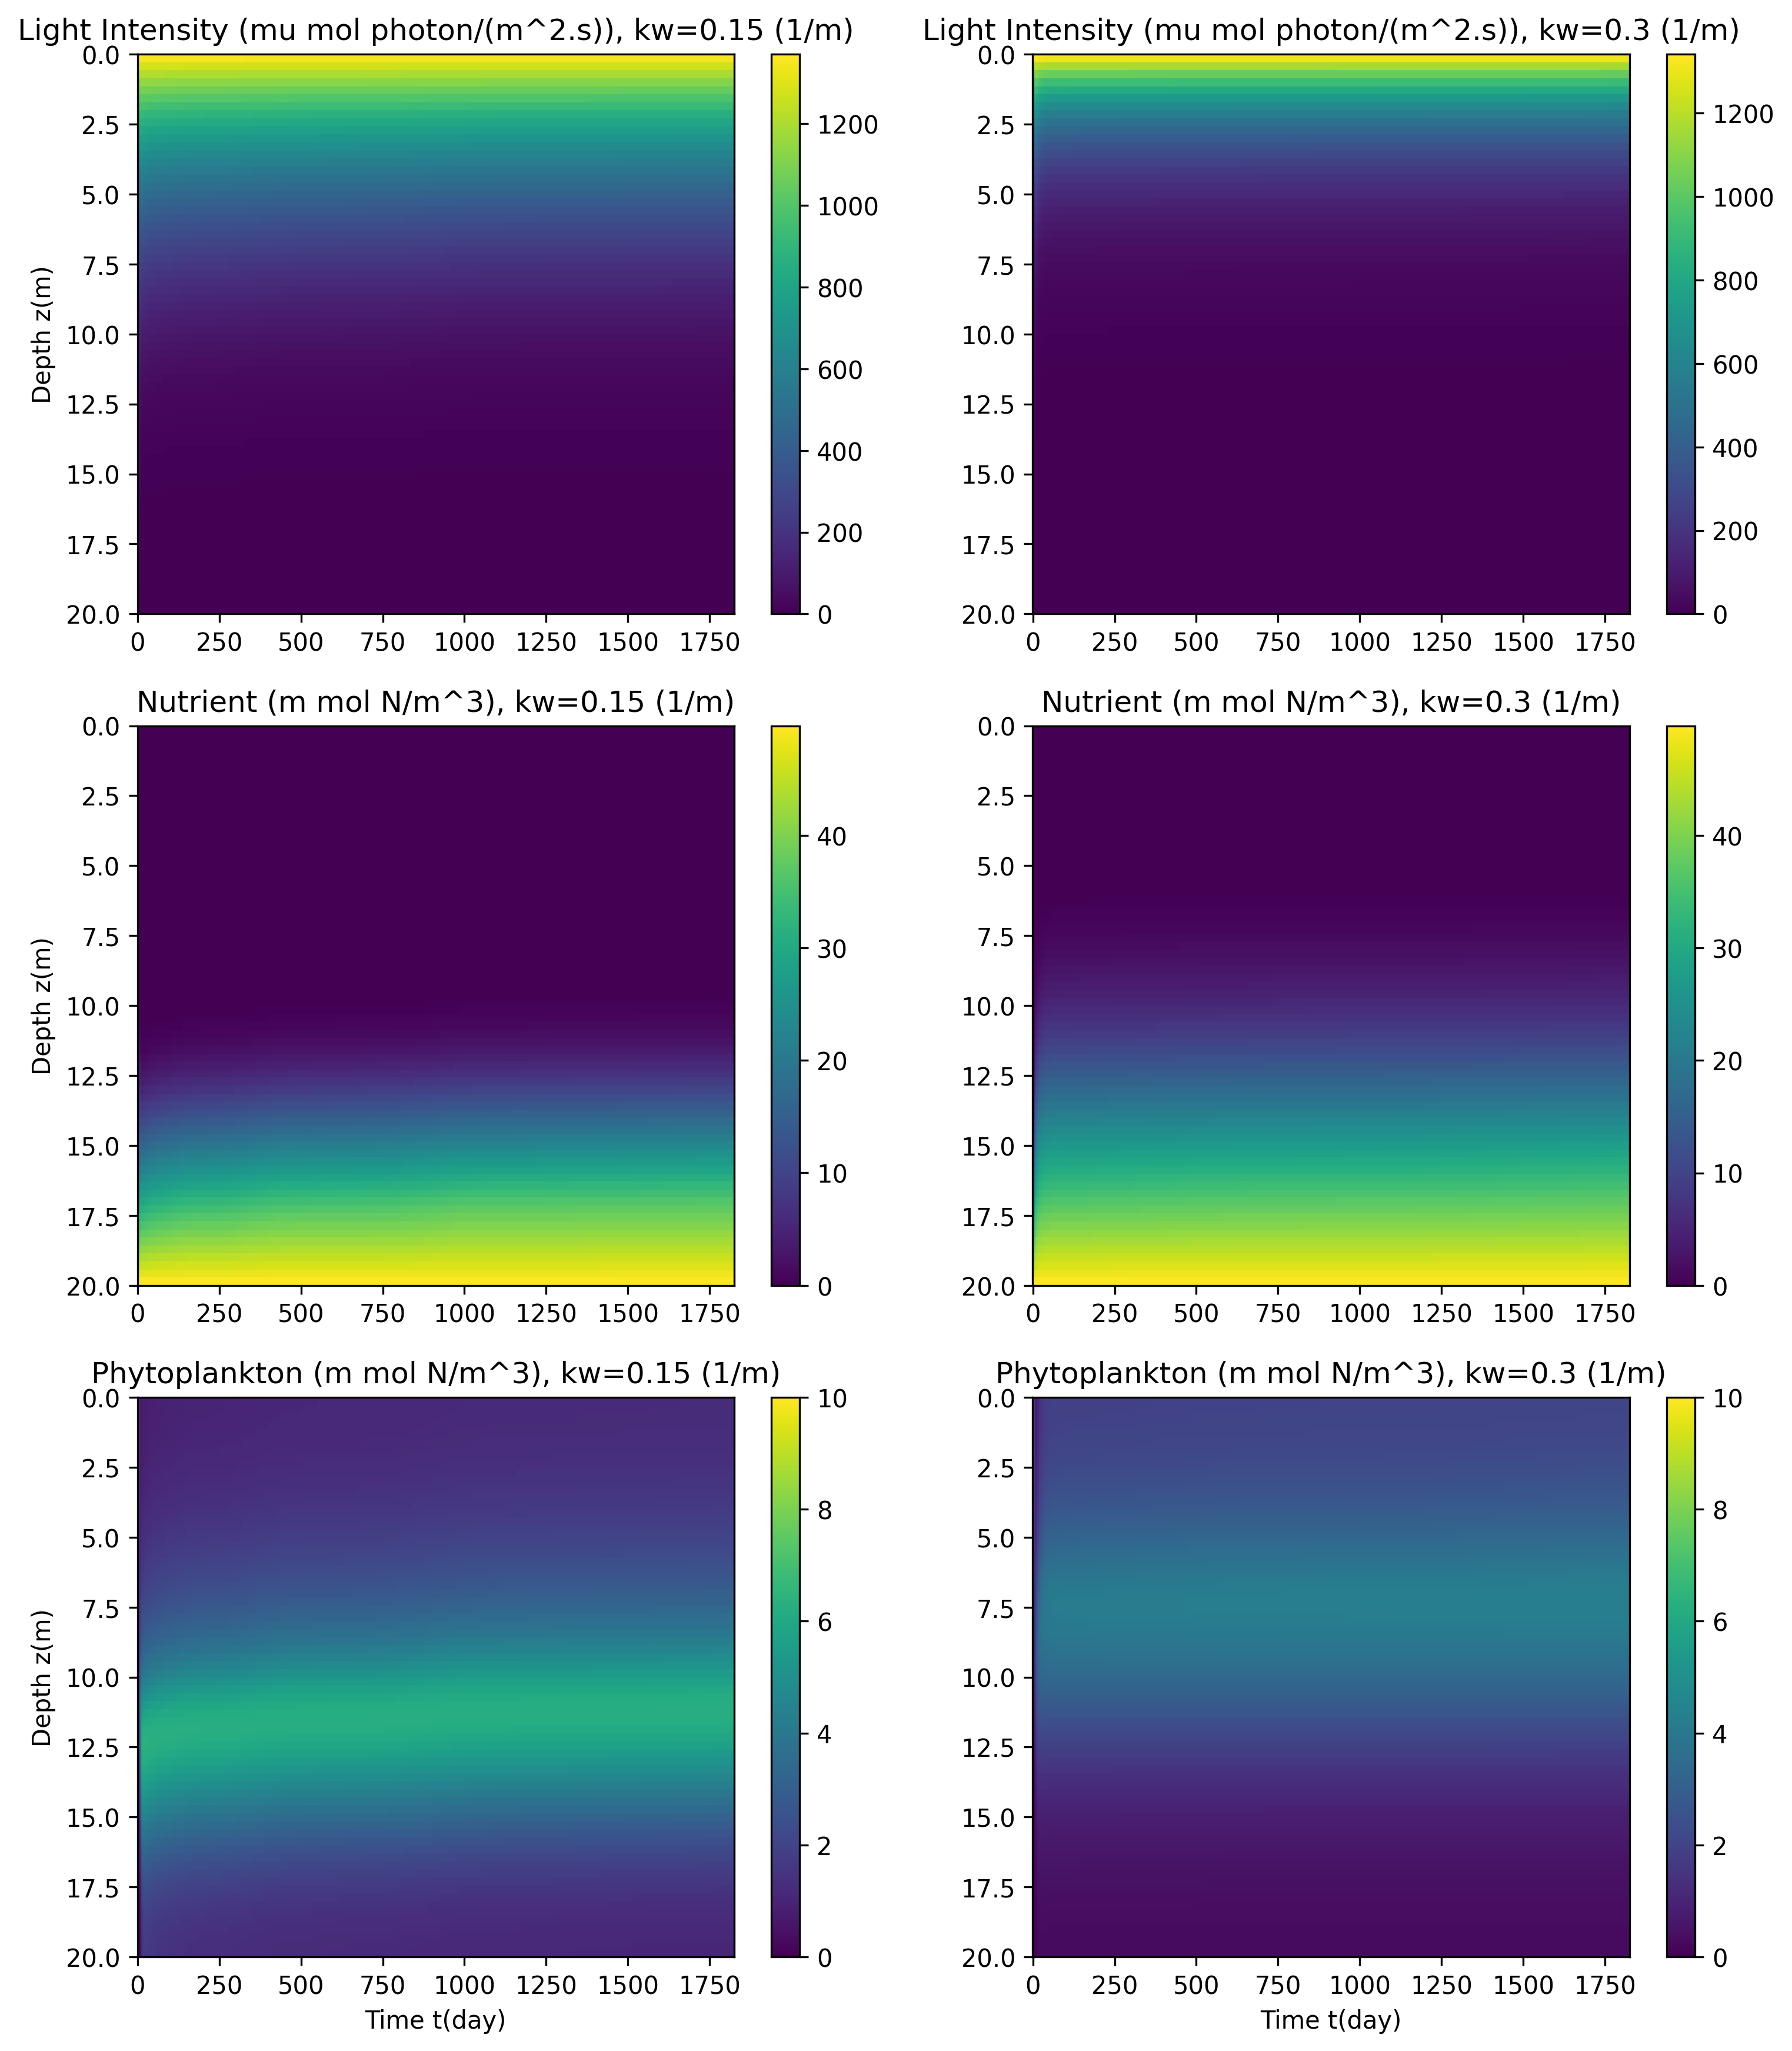

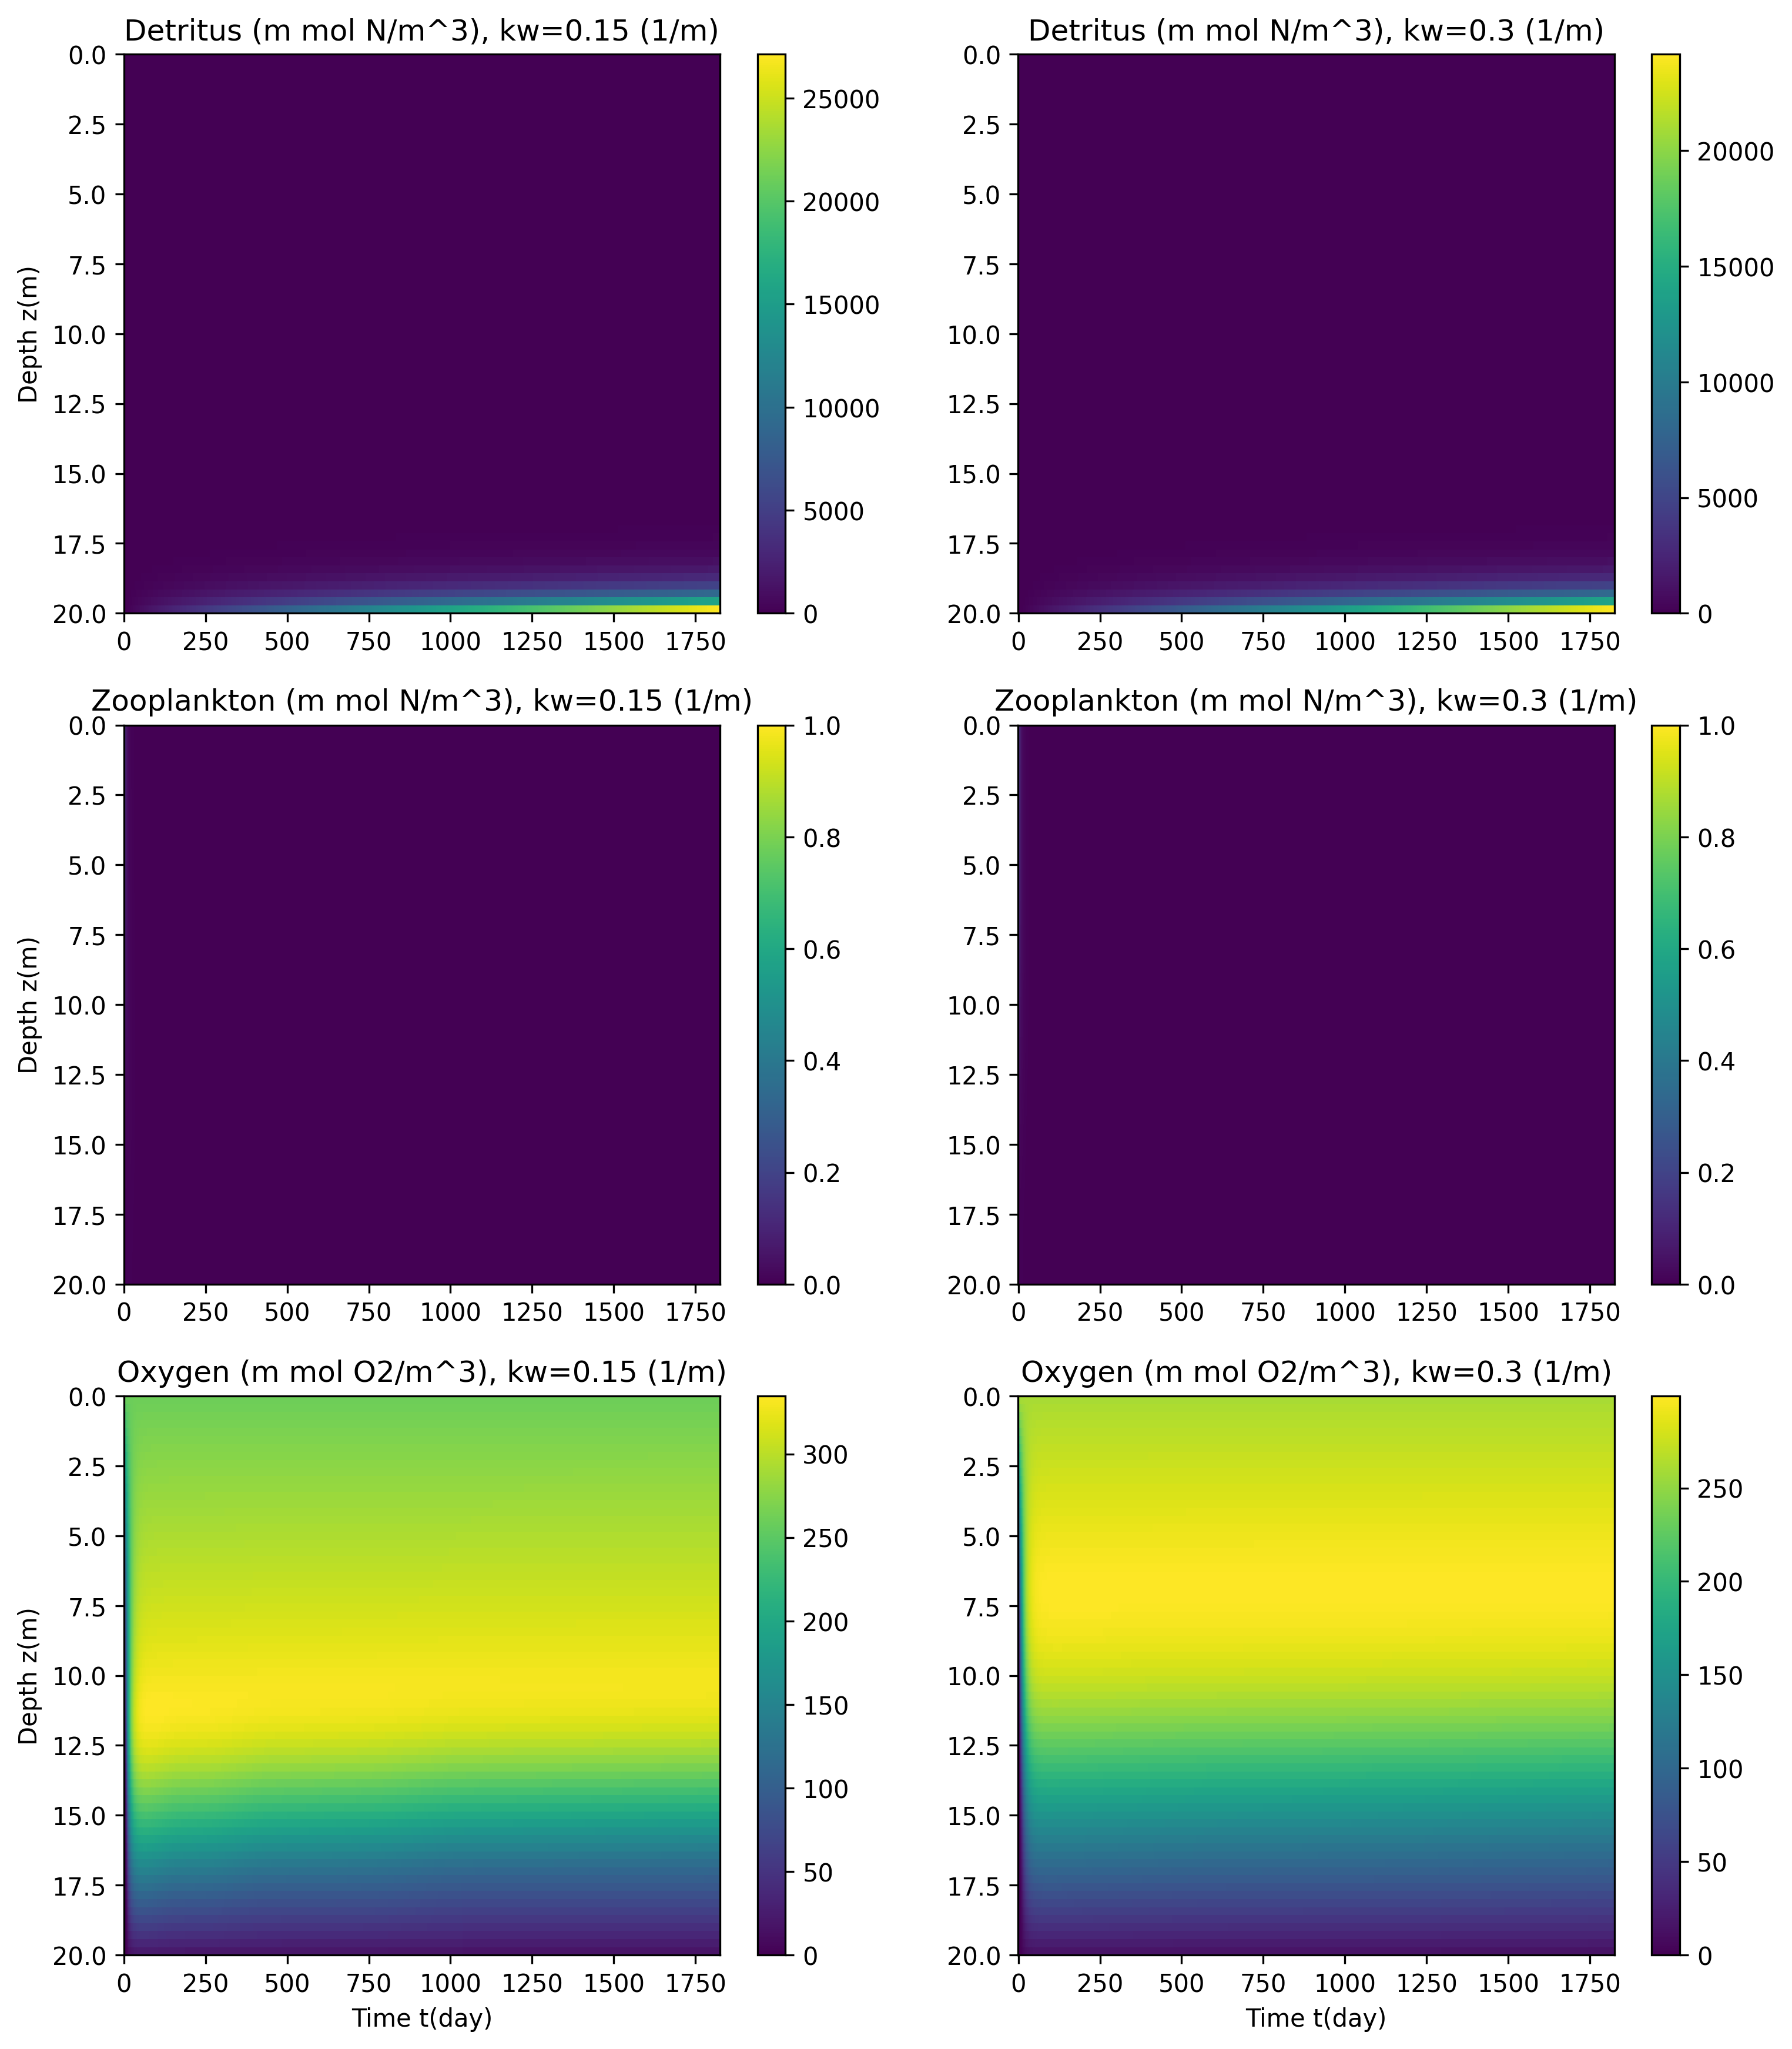

In [ ]:
# Q8

Phy_01, t, N1, P1, Z1, D1, O1, L1, z, p1= mainf(n=70,tend=5*365,Ndeep=50,N00=10,kw=0.15)
Phy_02, t, N2, P2, Z2, D2, O2, L2, z, p2= mainf(n=70,tend=5*365,Ndeep=50,N00=10,kw=0.3)

# Plotting N, P, Z

plt.figure(figsize=(11,10))
plt.subplot(2,2,1)
plt.plot(N1[:,-1],z,label='Nutrient N(mmol N/m^3)')
plt.plot(P1[:,-1],z,label='Phytoplankton P(mmol N/m^3)')
plt.plot(Z1[:,-1],z,label='Zooplankton Z(mmol N/m^3)')
plt.title('kw=0.15 (1/m)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()


plt.subplot(2,2,2)
plt.plot(N2[:,-1],z,'--',label='Nutrient N(mmol N/m^3)')
plt.plot(P2[:,-1],z,'--',label='Phytoplankton P(mmol N/m^3)')
plt.plot(Z2[:,-1],z,'--',label='Zooplankton Z(mmol N/m^3)')
plt.title('kw=0.3 (1/m)')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Plotting D 
plt.subplot(2,2,3)
plt.plot(D1[:,-1],z,label='Detritus D(mmol N/m^3), kw=0.15 (1/m)')
plt.plot(D2[:,-1],z,'--',label='Detritus D(mmol N/m^3), kw=0.3 (1/m)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Plotting O
plt.subplot(2,2,4)
plt.plot(O1[:,-1],z,label='Oxygen O(mmol O2/m^3), kw=0.15 (1/m)')
plt.plot(O2[:,-1],z,'--',label='Oxygen O(mmol O2/m^3), kw=0.3 (1/m)')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Plotting limiting factors on phytoplankton growth
plt.figure()
plt.plot(L1[:,-1]/(L1[:,-1]+p1.kL),z,label='Light Limitting Factor, kw=0.15 (1/m)')
plt.plot(N1[:,-1]/(N1[:,-1]+p1.kN),z,label='Nutrient Limitting Factor, kw=0.15 (1/m)')
plt.plot(L2[:,-1]/(L2[:,-1]+p2.kL),z,'--',label='Light Limitting Factor, kw=0.3 (1/m)')
plt.plot(N2[:,-1]/(N2[:,-1]+p2.kN),z,'--',label='Nutrient Limitting Factor, kw=0.3 (1/m)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()
plt.legend()

# Colormaps --------------------------------------------------------------------------------------------------------------------------

TT, ZZ = np.meshgrid(t,z)

# Plotting Light Colormap
plt.figure(figsize=(12,14),dpi=300)
plt.subplot(3,2,1)
plt.pcolormesh(TT, ZZ, L1, shading='auto', cmap='viridis')
plt.title('Light Intensity (mu mol photon/(m^2.s)), kw=0.15 (1/m)')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()


plt.subplot(3,2,2)
plt.pcolormesh(TT, ZZ, L2, shading='auto', cmap='viridis')
plt.title('Light Intensity (mu mol photon/(m^2.s)), kw=0.3 (1/m)')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Nutrient Colormap
plt.subplot(3,2,3)
plt.pcolormesh(TT, ZZ, N1, shading='auto', cmap='viridis')
plt.title('Nutrient (m mol N/m^3), kw=0.15 (1/m)')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,4)
plt.pcolormesh(TT, ZZ, N2, shading='auto', cmap='viridis')
plt.title('Nutrient (m mol N/m^3), kw=0.3 (1/m)')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Phytoplankton Colormap
plt.subplot(3,2,5)
plt.pcolormesh(TT, ZZ, P1, shading='auto', cmap='viridis')
plt.title('Phytoplankton (m mol N/m^3), kw=0.15 (1/m)')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.xlabel('Time t(day)')
plt.gca().invert_yaxis()

plt.subplot(3,2,6)
plt.pcolormesh(TT, ZZ, P2, shading='auto', cmap='viridis')
plt.title('Phytoplankton (m mol N/m^3), kw=0.3 (1/m)')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.xlabel('Time t(day)')
plt.gca().invert_yaxis()

# Plotting Nutrient Colormap
plt.figure(figsize=(12,14),dpi=300)
plt.subplot(3,2,1)
plt.pcolormesh(TT, ZZ, D1, shading='auto', cmap='viridis')
plt.title('Detritus (m mol N/m^3), kw=0.15 (1/m)')
plt.colorbar()
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,2)
plt.pcolormesh(TT, ZZ, D2, shading='auto', cmap='viridis')
plt.title('Detritus (m mol N/m^3), kw=0.3 (1/m)')
plt.colorbar()
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Zooplankton Colormap
plt.subplot(3,2,3)
plt.pcolormesh(TT, ZZ, Z1, shading='auto', cmap='viridis')
plt.title('Zooplankton (m mol N/m^3), kw=0.15 (1/m)')
plt.colorbar()
#plt.xlabel('Time (day)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,4)
plt.pcolormesh(TT, ZZ, Z2, shading='auto', cmap='viridis')
plt.title('Zooplankton (m mol N/m^3), kw=0.3 (1/m)')
plt.colorbar()
#plt.xlabel('Time (day)')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

# Plotting Oxygen Colormap
plt.subplot(3,2,5)
plt.pcolormesh(TT, ZZ, O1, shading='auto', cmap='viridis')
plt.title('Oxygen (m mol O2/m^3), kw=0.15 (1/m)')
plt.colorbar()
plt.xlabel('Time t(day)')
plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

plt.subplot(3,2,6)
plt.pcolormesh(TT, ZZ, O2, shading='auto', cmap='viridis')
plt.title('Oxygen (m mol O2/m^3), kw=0.3 (1/m)')
plt.colorbar()
plt.xlabel('Time t(day)')
#plt.ylabel('Depth z(m)')
plt.gca().invert_yaxis()

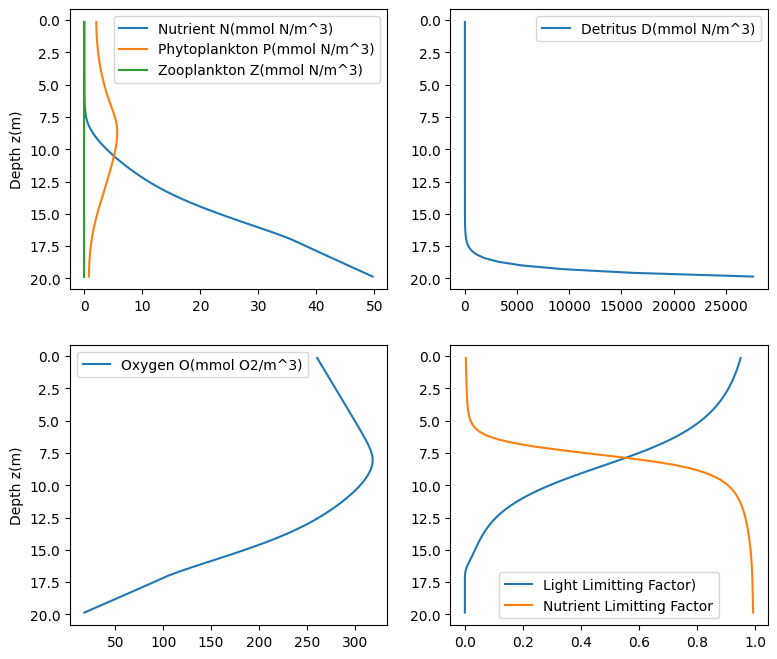

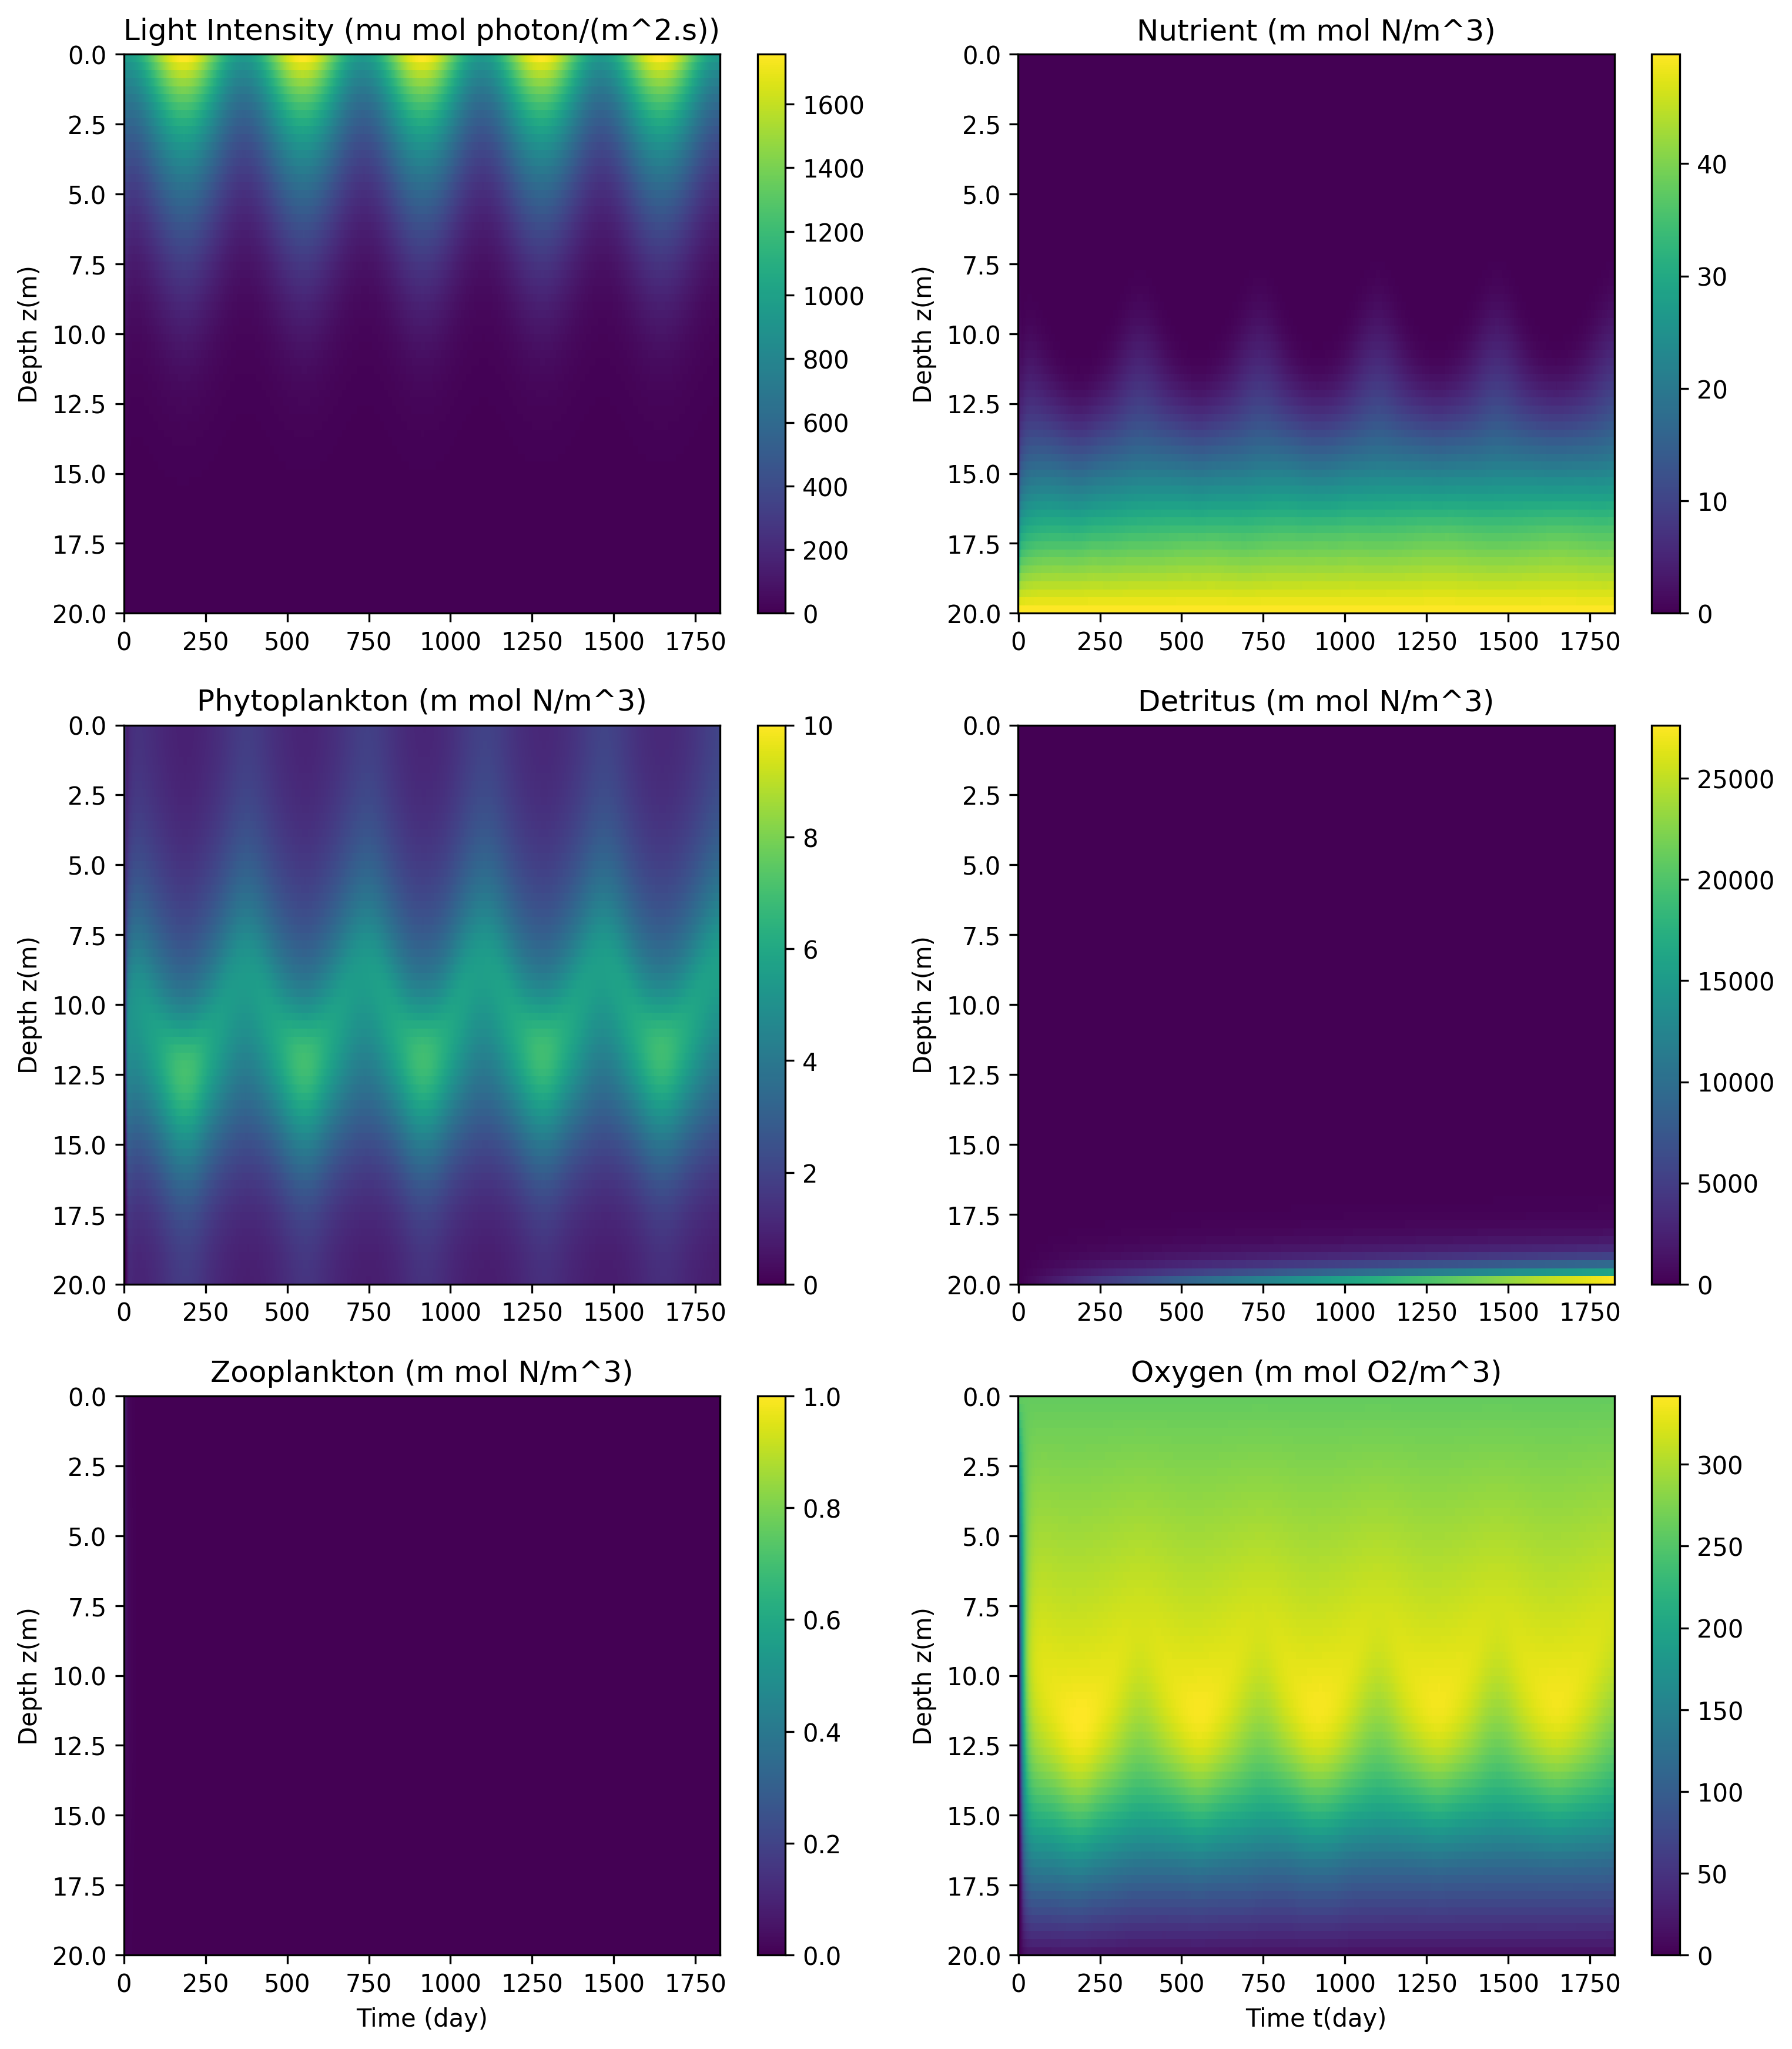

In [24]:
Phy_02, t, N2, P2, Z2, D2, O2, L2, z, p2= mainf(n=70,tend=5*365,Ndeep=50,N00=10,kw=0.15)